In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("SuperStoreOrders.csv")

In [ ]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [ ]:
df.shape

(51290, 21)

In [ ]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [ ]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [ ]:
df.describe(include="object")

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,order_priority
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,25035,1430,1464,4,795,3,1094,147,7,13,10292,3,17,3788,2246,4
top,CA-2014-100111,18-06-2014,22-11-2014,Standard Class,Muhammed Yedwab,Consumer,California,United States,APAC,Central,OFF-AR-10003651,Office Supplies,Binders,Staples,13,Medium
freq,14,135,130,30775,108,26518,2001,9994,11002,11117,35,31273,6152,227,589,29433


In [ ]:
df.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


In [ ]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [ ]:
df.dtypes

,0
order_id,object
order_date,object
ship_date,object
ship_mode,object
customer_name,object
segment,object
state,object
country,object
market,object
region,object


In [ ]:
df.nunique()

,0
order_id,25035
order_date,1430
ship_date,1464
ship_mode,4
customer_name,795
segment,3
state,1094
country,147
market,7
region,13


In [ ]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print("="*60)
    print(col)
    print(df[col].unique())
    print("Total Unique :", df[col].nunique())

order_id
['AG-2011-2040' 'IN-2011-47883' 'HU-2011-1220' ... 'MX-2014-108574'
 'MO-2014-2560' 'CA-2014-156720']
Total Unique : 25035
order_date
['1/1/2011' '2/1/2011' '3/1/2011' ... '29-12-2014' '30-12-2014'
 '31-12-2014']
Total Unique : 1430
ship_date
['6/1/2011' '8/1/2011' '5/1/2011' ... '5/1/2015' '6/1/2015' '7/1/2015']
Total Unique : 1464
ship_mode
['Standard Class' 'Second Class' 'Same Day' 'First Class']
Total Unique : 4
customer_name
['Toby Braunhardt' 'Joseph Holt' 'Annie Thurman' 'Eugene Moren'
 'Magdelene Morse' 'Kean Nguyen' 'Ken Lonsdale' 'Lindsay Williams'
 'Larry Blacks' 'Dorothy Dickinson' 'Dennis Pardue' 'Stewart Visinsky'
 "Jas O'Carroll" 'Chris McAfee' 'Nat Gilpin' 'Jack Garza'
 'Russell Applegate' 'Maya Herman' 'Beth Thompson' 'Arthur Prichep'
 'Arthur Wiediger' 'Grant Thornton' 'Darren Powers' 'Bradley Drucker'
 'Jasper Cacioppo' 'Jennifer Halladay' 'Michael Granlund' 'Phillina Ober'
 'Shaun Weien' 'Shahid Hopkins' 'Brosina Hoffman' 'Robert Dilbeck'
 'Grace Kelly' 'K

In [ ]:
df.corr(numeric_only=True)

,quantity,discount,profit,shipping_cost,year
quantity,1.000000,-0.019875,0.104743,0.272649,-0.005049
discount,-0.019875,1.000000,-0.316375,-0.079056,-0.005894
profit,0.104743,-0.316375,1.000000,0.357033,0.002661
shipping_cost,0.272649,-0.079056,0.357033,1.000000,-0.003136
year,-0.005049,-0.005894,0.002661,-0.003136,1.000000


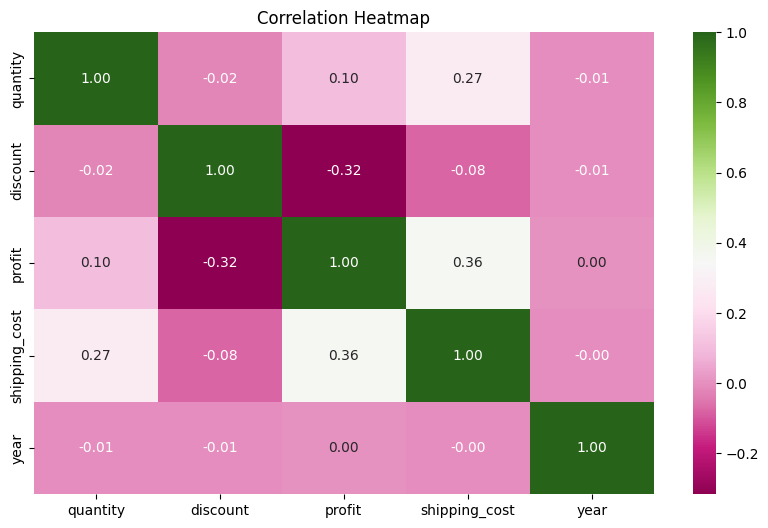

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="PiYG",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# data cleaning

In [ ]:
df.head(2)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sales,quantity,discount,profit,shipping_cost,order_priority,year,Processing_Days,Month,Quarter
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,408,2,0.0,106.140,35.46,Medium,2011,5,January,1
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,120,3,0.1,36.036,9.72,Medium,2011,7,January,1


In [ ]:
df["order_date"] = pd.to_datetime(df["order_date"], format="mixed", dayfirst=True)
df["ship_date"] = pd.to_datetime(df["ship_date"], format="mixed", dayfirst=True)

In [ ]:
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")

In [ ]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sales,quantity,discount,profit,shipping_cost,order_priority,year,Processing_Days,Month,Quarter
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,408.0,2,0.0,106.140,35.46,Medium,2011,5,January,1
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,120.0,3,0.1,36.036,9.72,Medium,2011,7,January,1
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,66.0,4,0.0,29.640,8.17,High,2011,4,January,1
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,45.0,3,0.5,-26.055,4.82,High,2011,4,January,1
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,114.0,5,0.1,37.770,4.70,Medium,2011,7,January,1




## *   **There are no null values**
## *   **There are no duplicates**



# **FEATURE ENGINEERING**

In [ ]:
df["Processing_Days"] = (
    df["ship_date"] - df["order_date"]).dt.days

In [ ]:
df["Month"] = df["order_date"].dt.month_name()

In [ ]:
df["Quarter"] = df["order_date"].dt.quarter

In [ ]:
df["Profit_Margin"] = ((df["profit"] / df["sales"]) * 100).round(2)

In [ ]:
df.to_csv("cleaned_superstore_data.csv", index=False)